# VANET Intrusion Detection System

**Dataset:** v2x_dataset_Main_run.csv (466K rows x 49 cols)  
**Labels:** normal | sybil | DDoS | blackhole  
**Models:** Random Forest + XGBoost (no SMOTE)  

**Fixes applied:**
1. All syntax errors repaired
2. Stratified group split by car_id (prevents vehicle identity leakage)
3. `timestamp` dropped (temporal/simulation leakage)
4. `norm_speed` dropped (redundant linear transform of speed_mps)
5. Class imbalance handled via class_weight / sample_weight

In [1]:
import os, time, warnings
import joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, ConfusionMatrixDisplay)
from sklearn.feature_selection import mutual_info_classif
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
OUTPUT_DIR = 'model_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('All imports loaded.')

All imports loaded.


## 1. Load Dataset

In [2]:
t0 = time.time()
df = pd.read_csv('v2x_dataset_Main_run.csv')
print(f'Shape: {df.shape}  |  Loaded in {time.time()-t0:.1f}s')
df.head()

Shape: (466454, 49)  |  Loaded in 3.3s


,timestamp,car_id,event_type,label,pos_x,pos_y,speed_mps,distance_moved,position_changes,avg_speed,...,network_load,sybil_score,ddos_score,blackhole_score,norm_send_rate,norm_recv_rate,norm_bytes_sent,norm_attack_rate,norm_speed,norm_pkt_size
0,0.2,0,beacon_sent,sybil,2415.00,1578.00,0.00000,2884.84,1,0.0,...,1.0,0.0,0,0,0.066667,0.0,0.000092,0.000,0.000000,0.061333
1,0.2,0,sybil_sent,sybil,2424.26,1524.53,7.51562,2884.84,1,0.0,...,2.0,1.0,0,0,0.066667,0.0,0.000184,0.002,0.150312,0.061333
2,0.2,0,sybil_sent,sybil,2585.46,1620.02,1.75702,2884.84,1,0.0,...,3.0,2.0,0,0,0.066667,0.0,0.000276,0.004,0.035140,0.061333
3,0.2,0,sybil_sent,sybil,2336.16,1465.98,17.31850,2884.84,1,0.0,...,4.0,3.0,0,0,0.066667,0.0,0.000368,0.006,0.346370,0.061333
4,0.2,0,sybil_sent,sybil,2552.07,1445.87,4.91019,2884.84,1,0.0,...,5.0,4.0,0,0,0.066667,0.0,0.000460,0.008,0.098204,0.061333


## 2. Exploratory Data Analysis

In [3]:
label_counts = df['label'].value_counts()
print('Label Distribution:')
print(label_counts)
print(f'\nTotal samples: {len(df):,}')

Label Distribution:
label
normal       280478
sybil        148950
ddos          24677
blackhole     12349
Name: count, dtype: int64

Total samples: 466,454


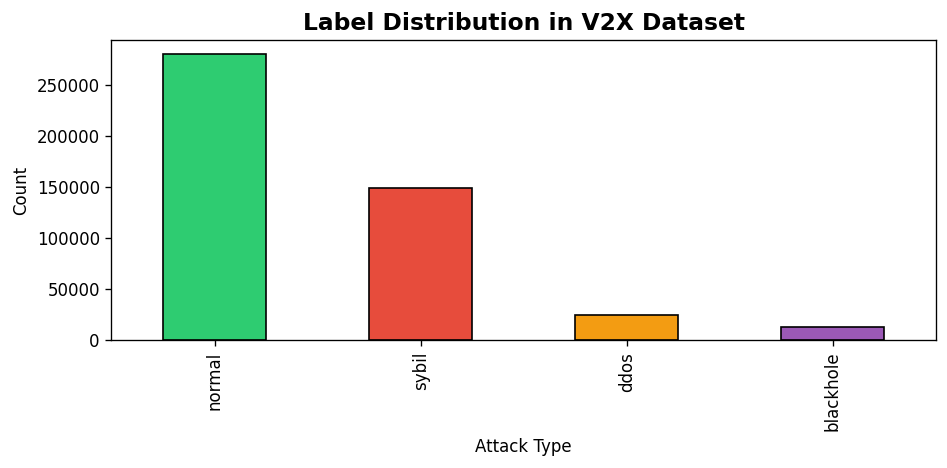

In [4]:
fig, ax = plt.subplots(figsize=(8,4))

colors = ['#2ecc71','#e74c3c','#f39c12','#9b59b6']

label_counts.plot.bar(ax=ax, color=colors, edgecolor='black')

ax.set_title('Label Distribution in V2X Dataset', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Attack Type')

plt.tight_layout()
plt.show()

In [5]:
missing = df.isnull().sum()
print(f'Total missing values: {missing.sum()}')
if missing.sum() == 0:
    print('No missing values!')
df.describe()

Total missing values: 0
No missing values!


,timestamp,car_id,pos_x,pos_y,speed_mps,distance_moved,position_changes,avg_speed,pkt_size_bytes,is_fake,...,network_load,sybil_score,ddos_score,blackhole_score,norm_send_rate,norm_recv_rate,norm_bytes_sent,norm_attack_rate,norm_speed,norm_pkt_size
count,466454.000000,466454.000000,466454.000000,466454.000000,466454.000000,466454.000000,466454.000000,466454.000000,466454.000000,466454.000000,...,466454.000000,466454.000000,466454.0,466454.0,466454.000000,466454.000000,466454.000000,466454.000000,466454.000000,466454.000000
mean,205.019362,32.230458,1718.343036,1672.900656,13.310267,4166.229548,1046.239113,11.736284,89.564373,0.133079,...,525.693995,16.000743,0.0,0.0,0.651429,0.756072,0.262862,0.032001,0.266205,0.059710
std,98.591613,31.320812,702.683086,286.642559,3.743094,1175.933747,724.199121,2.853585,14.769762,0.339660,...,139.223411,23.374739,0.0,0.0,0.109608,0.198966,0.321099,0.046749,0.074862,0.009847
min,0.200000,0.000000,0.341558,1018.360000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,131.400000,3.000000,1192.582500,1394.642500,12.743200,3381.150000,417.000000,11.712500,92.000000,0.000000,...,425.678000,0.000000,0.0,0.0,0.667058,0.666667,0.049404,0.000000,0.254863,0.061333
50%,205.200000,24.000000,1914.210000,1670.930000,13.910800,4099.950000,957.000000,12.743400,92.000000,0.000000,...,547.879000,0.000000,0.0,0.0,0.667319,0.667335,0.120428,0.000000,0.278215,0.061333
75%,280.075000,53.000000,2372.520000,1926.850000,13.962300,5020.960000,1618.000000,13.190800,92.000000,0.000000,...,650.093000,50.016800,0.0,0.0,0.668075,1.000000,0.297528,0.100034,0.279247,0.061333
max,397.500000,132.000000,2649.620000,2319.490000,29.999100,6299.120000,2860.000000,13.572300,92.000000,1.000000,...,715.585000,100.000000,0.0,0.0,1.000000,1.000000,1.000000,0.200000,0.599983,0.061333


## 3. Drop Leaky / Non-Predictive Columns

In [6]:
LEAK_COLS = [
    # Identifiers / pre-computed labels
    'event_type','is_fake','fake_id',
    'sybil_score','ddos_score','blackhole_score',
    # Attacker-side counters
    'my_attack_packets','my_fake_ids_sent','my_ddos_packets','my_dropped',
    'attack_rate','ddos_rate_actual',
    # Derived ratios directly encoding attack identity
    'fake_ratio','ddos_ratio','blackhole_ratio','drop_ratio','norm_attack_rate',
    # Zero/near-zero variance
    'avg_pkt_size_sent','norm_pkt_size',
    # Global/Network-wide metrics
    'global_beacons_sent','global_beacons_rcvd',
    'global_attack_pkts','global_dropped','network_load',
    # Simulation artifacts
    'my_beacons_sent','my_beacons_received',
    'beacon_send_rate','beacon_recv_rate',
    'total_bytes_sent','total_bytes_rcvd',
    'avg_pkt_size_rcvd','throughput_bps',
    'send_recv_ratio','active_duration',
    'beacon_regularity','norm_send_rate',
    'norm_recv_rate','norm_bytes_sent',
    # Temporal leakage - simulation timestamp
    'timestamp',
    # Redundant (linear transform of speed_mps)
    'norm_speed',
]
dropped = [c for c in LEAK_COLS if c in df.columns]
df.drop(columns=dropped, inplace=True)
print(f'Dropped {len(dropped)} leaky / ID / redundant columns')
print(f'Remaining columns: {df.shape[1]}')
print('Feature columns:', [c for c in df.columns if c not in ('label','car_id')])

Dropped 40 leaky / ID / redundant columns
Remaining columns: 9
Feature columns: ['pos_x', 'pos_y', 'speed_mps', 'distance_moved', 'position_changes', 'avg_speed', 'pkt_size_bytes']


## 4. Encode Labels

In [7]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
label_names = list(le.classes_)
print(f'Label encoding: {dict(zip(label_names, le.transform(label_names)))}')

Label encoding: {'blackhole': np.int64(0), 'ddos': np.int64(1), 'normal': np.int64(2), 'sybil': np.int64(3)}


## 5. Feature / Target Split

In [8]:
FEATURE_COLS = [c for c in df.columns if c not in ('label','label_enc','car_id')]
X = df[FEATURE_COLS].copy()
y = df['label_enc'].copy()
groups = df['car_id'].copy()
if X.isnull().sum().sum() > 0:
    X.fillna(X.median(), inplace=True)
    print('Filled missing values with column medians.')
obj_cols = X.select_dtypes(include='object').columns.tolist()
if obj_cols:
    print(f'Encoding categorical columns: {obj_cols}')
    for col in obj_cols:
        X[col] = LabelEncoder().fit_transform(X[col].astype(str))
print(f'Final feature matrix: {X.shape}')
print('Features:', FEATURE_COLS)

Final feature matrix: (466454, 7)
Features: ['pos_x', 'pos_y', 'speed_mps', 'distance_moved', 'position_changes', 'avg_speed', 'pkt_size_bytes']


## 6. Feature Selection (Mutual Information)

In [9]:
sample_idx = np.random.RandomState(42).choice(len(X), size=min(50000,len(X)), replace=False)
mi_scores = mutual_info_classif(X.iloc[sample_idx], y.iloc[sample_idx], random_state=42)
mi_df = pd.DataFrame({'feature': FEATURE_COLS, 'mi_score': mi_scores}).sort_values('mi_score', ascending=False)
print('Mutual Information scores:')
mi_df

Mutual Information scores:


,feature,mi_score
5,avg_speed,0.286553
3,distance_moved,0.218778
2,speed_mps,0.157227
4,position_changes,0.137824
6,pkt_size_bytes,0.120951
1,pos_y,0.078583
0,pos_x,0.075591


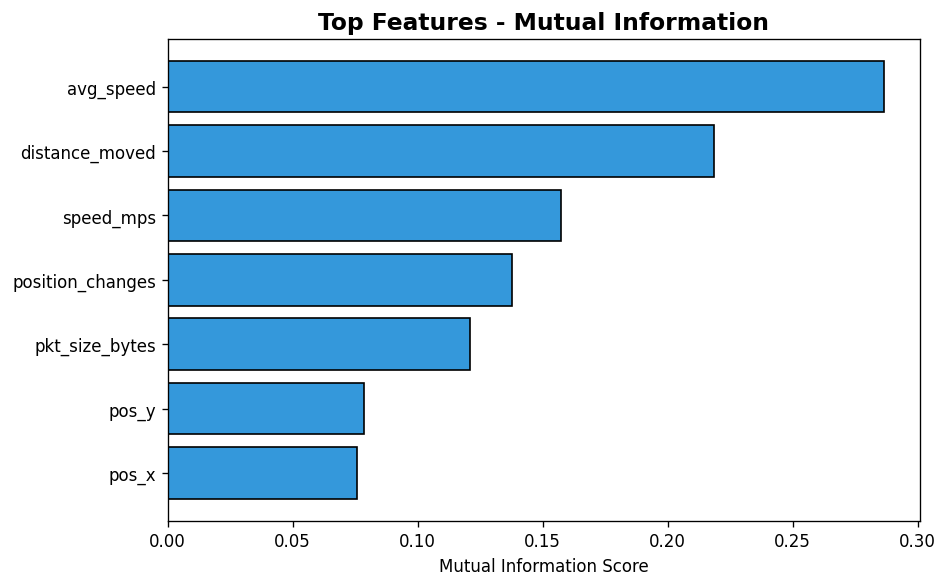

In [10]:
fig, ax = plt.subplots(figsize=(8,5))
top = mi_df.head(15)
ax.barh(top['feature'][::-1], top['mi_score'][::-1], color='#3498db', edgecolor='black')
ax.set_xlabel('Mutual Information Score')
ax.set_title('Top Features - Mutual Information', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
TOP_FEATURES = mi_df.loc[mi_df['mi_score']>0.01, 'feature'].tolist()
if len(TOP_FEATURES) < 5:
    TOP_FEATURES = mi_df.head(15)['feature'].tolist()
print(f'Selected {len(TOP_FEATURES)} features: {TOP_FEATURES}')
X = X[TOP_FEATURES]

Selected 7 features: ['avg_speed', 'distance_moved', 'speed_mps', 'position_changes', 'pkt_size_bytes', 'pos_y', 'pos_x']


## 7. Train/Test Split - Stratified Group Split by car_id

**Why stratified-group?**
1. Plain random split: same car in train+test -> vehicle identity leak
2. Plain GroupShuffleSplit: doesn't stratify by label -> entire class (e.g. DDoS) can have 0 test samples

**Solution:** split cars within each label group ~80/20

In [12]:
rng = np.random.RandomState(42)
car_labels = df.groupby('car_id')['label_enc'].agg(lambda s: s.mode()[0])
train_cars_list, test_cars_list = [], []
for lv in sorted(car_labels.unique()):
    cars = car_labels[car_labels == lv].index.values.copy()
    rng.shuffle(cars)
    n_test = max(1, int(len(cars)*0.20))
    test_cars_list.extend(cars[:n_test])
    train_cars_list.extend(cars[n_test:])
train_car_set = set(train_cars_list)
test_car_set = set(test_cars_list)
train_idx = np.where(groups.isin(train_car_set))[0]
test_idx = np.where(groups.isin(test_car_set))[0]

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Unique cars in train: {groups.iloc[train_idx].nunique()}')
print(f'Unique cars in test : {groups.iloc[test_idx].nunique()}')
overlap = set(groups.iloc[train_idx].unique()) & set(groups.iloc[test_idx].unique())
print(f'Car overlap: {len(overlap)}  (should be 0)')
assert len(overlap) == 0, 'LEAKAGE: same car in train AND test!'

Train: (375261, 7)  |  Test: (91193, 7)
Unique cars in train: 107
Unique cars in test : 26
Car overlap: 0  (should be 0)


In [13]:
print('Per-class sample counts:')
for cn in label_names:
    ci = le.transform([cn])[0]
    print(f'  {cn:12s}  train={int((y_train==ci).sum()):7,}  test={int((y_test==ci).sum()):7,}')
assert all((y_test==c).sum()>0 for c in range(len(label_names))), 'Class with 0 test samples!'

Per-class sample counts:
  blackhole     train=  9,854  test=  2,495
  ddos          train= 19,816  test=  4,861
  normal        train=225,963  test= 54,515
  sybil         train=119,628  test= 29,322


In [14]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

## 8. Random Forest

In [15]:
rf = RandomForestClassifier(n_estimators=200, max_depth=25, min_samples_split=5,
                            min_samples_leaf=2, class_weight='balanced',
                            random_state=42, n_jobs=-1)
t_start = time.time()
rf.fit(X_train_sc, y_train)
rf_time = time.time() - t_start
y_pred_rf = rf.predict(X_test_sc)
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1w = f1_score(y_test, y_pred_rf, average='weighted')
rf_f1m = f1_score(y_test, y_pred_rf, average='macro')
print(f'Accuracy: {rf_acc:.4f}  F1w: {rf_f1w:.4f}  F1m: {rf_f1m:.4f}  Time: {rf_time:.1f}s')
print(classification_report(y_test, y_pred_rf, target_names=label_names))

Accuracy: 0.8264  F1w: 0.8270  F1m: 0.7101  Time: 44.8s
              precision    recall  f1-score   support

   blackhole       1.00      1.00      1.00      2495
        ddos       0.11      0.11      0.11      4861
      normal       0.84      0.88      0.86     54515
       sybil       0.92      0.83      0.87     29322

    accuracy                           0.83     91193
   macro avg       0.72      0.71      0.71     91193
weighted avg       0.83      0.83      0.83     91193



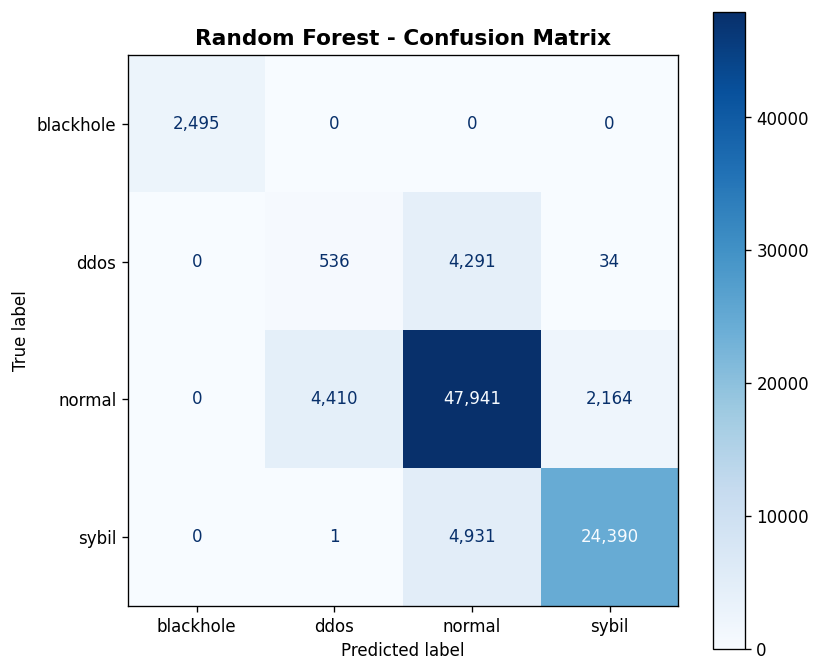

In [16]:
fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
                       display_labels=label_names).plot(ax=ax, cmap='Blues', values_format=',')
ax.set_title('Random Forest - Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. XGBoost

In [17]:
class_counts = np.bincount(y_train)
sample_weights = np.array([len(y_train)/(len(class_counts)*class_counts[yi]) for yi in y_train])
xgb = XGBClassifier(n_estimators=300, max_depth=10, learning_rate=0.1, subsample=0.8,
                    colsample_bytree=0.8, objective='multi:softmax', num_class=len(label_names),
                    eval_metric='mlogloss', use_label_encoder=False, random_state=42, n_jobs=-1)
t_start = time.time()
xgb.fit(X_train_sc, y_train, sample_weight=sample_weights)
xgb_time = time.time() - t_start
y_pred_xgb = xgb.predict(X_test_sc)
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_f1w = f1_score(y_test, y_pred_xgb, average='weighted')
xgb_f1m = f1_score(y_test, y_pred_xgb, average='macro')
print(f'Accuracy: {xgb_acc:.4f}  F1w: {xgb_f1w:.4f}  F1m: {xgb_f1m:.4f}  Time: {xgb_time:.1f}s')
print(classification_report(y_test, y_pred_xgb, target_names=label_names))

Accuracy: 0.7890  F1w: 0.7993  F1m: 0.6906  Time: 22.9s
              precision    recall  f1-score   support

   blackhole       1.00      1.00      1.00      2495
        ddos       0.07      0.10      0.08      4861
      normal       0.84      0.80      0.82     54515
       sybil       0.86      0.86      0.86     29322

    accuracy                           0.79     91193
   macro avg       0.69      0.69      0.69     91193
weighted avg       0.81      0.79      0.80     91193



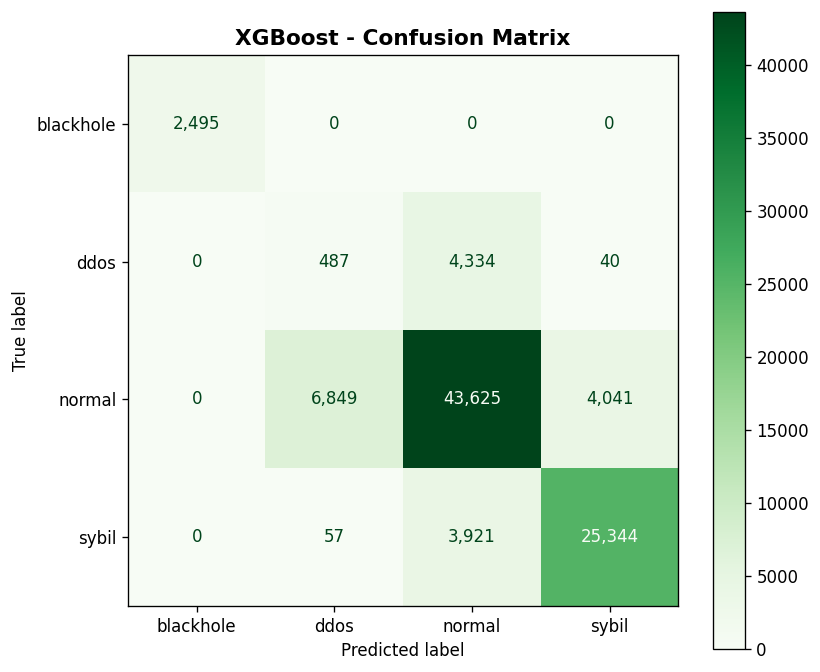

In [18]:
fig, ax = plt.subplots(figsize=(7,6))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_xgb),
                       display_labels=label_names).plot(ax=ax, cmap='Greens', values_format=',')
ax.set_title('XGBoost - Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Model Comparison

In [19]:
results = {
    'Random Forest': {'accuracy':rf_acc,'f1_weighted':rf_f1w,'f1_macro':rf_f1m,'train_time':rf_time,'model':rf,'y_pred':y_pred_rf},
    'XGBoost': {'accuracy':xgb_acc,'f1_weighted':xgb_f1w,'f1_macro':xgb_f1m,'train_time':xgb_time,'model':xgb,'y_pred':y_pred_xgb},
}
comp = pd.DataFrame({n:{'Accuracy':r['accuracy'],'F1 Weighted':r['f1_weighted'],'F1 Macro':r['f1_macro'],'Time (s)':round(r['train_time'],1)} for n,r in results.items()}).T
comp

,Accuracy,F1 Weighted,F1 Macro,Time (s)
Random Forest,0.826401,0.826963,0.710082,44.8
XGBoost,0.788997,0.799254,0.690590,22.9


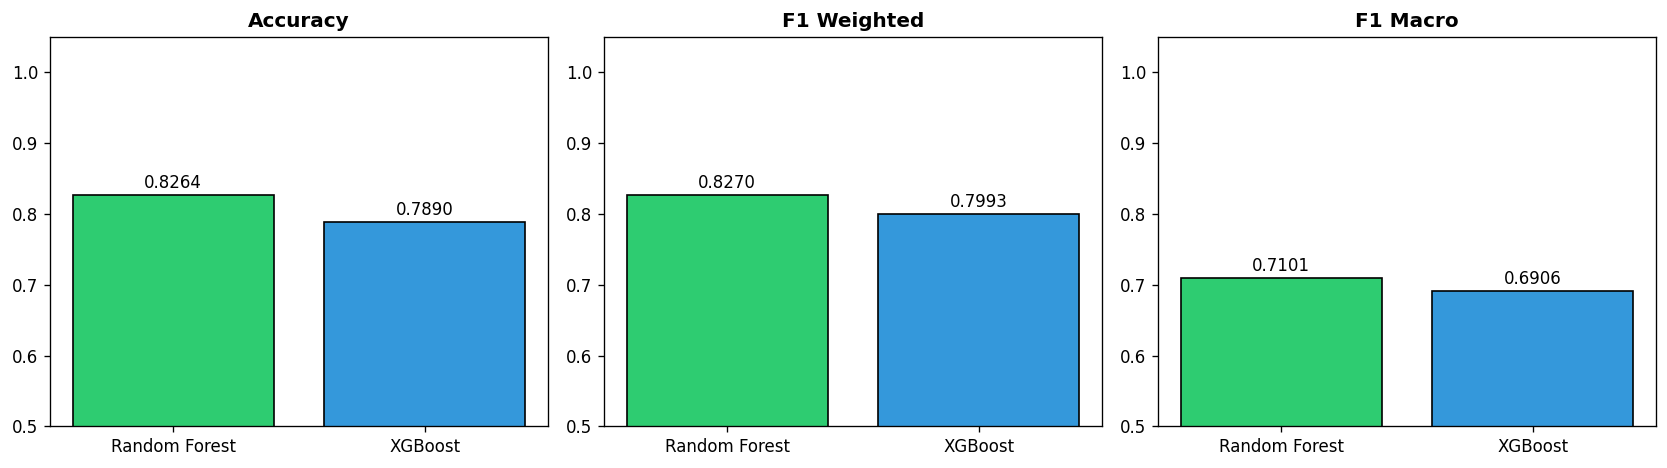

In [20]:
fig, axes = plt.subplots(1,3,figsize=(14,4))
for ax,m,title in zip(axes,['accuracy','f1_weighted','f1_macro'],['Accuracy','F1 Weighted','F1 Macro']):
    vals = [results[n][m] for n in results]
    bars = ax.bar(list(results.keys()), vals, color=['#2ecc71','#3498db'], edgecolor='black')
    ax.set_title(title, fontweight='bold'); ax.set_ylim(0.5,1.05)
    for b,v in zip(bars,vals): ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 11. Save Best Model

In [21]:
best_name = max(results, key=lambda k: results[k]['f1_weighted'])
best_model = results[best_name]['model']
joblib.dump(best_model, os.path.join(OUTPUT_DIR,'best_model.joblib'))
joblib.dump(scaler, os.path.join(OUTPUT_DIR,'scaler.joblib'))
joblib.dump(le, os.path.join(OUTPUT_DIR,'label_encoder.joblib'))
joblib.dump(TOP_FEATURES, os.path.join(OUTPUT_DIR,'feature_list.joblib'))
print(f'Best model: {best_name}')
print(f'Accuracy: {results[best_name]["accuracy"]:.4f}')
print(f'F1w: {results[best_name]["f1_weighted"]:.4f}  F1m: {results[best_name]["f1_macro"]:.4f}')
print(f'Features: {len(TOP_FEATURES)}')
print(f'Saved to: {OUTPUT_DIR}/')

Best model: Random Forest
Accuracy: 0.8264
F1w: 0.8270  F1m: 0.7101
Features: 7
Saved to: model_outputs/


## 12. Inference Demo

In [22]:
lm = joblib.load(os.path.join(OUTPUT_DIR,'best_model.joblib'))
ls = joblib.load(os.path.join(OUTPUT_DIR,'scaler.joblib'))
ll = joblib.load(os.path.join(OUTPUT_DIR,'label_encoder.joblib'))
lf = joblib.load(os.path.join(OUTPUT_DIR,'feature_list.joblib'))
sample = X_test.sample(5, random_state=123)
preds = ll.inverse_transform(lm.predict(ls.transform(sample[lf])))
actuals = ll.inverse_transform(y_test.loc[sample.index].values)
pd.DataFrame({'Predicted':preds,'Actual':actuals,'Correct':preds==actuals}, index=sample.index)

,Predicted,Actual,Correct
346967,sybil,normal,False
226098,normal,normal,True
38251,sybil,sybil,True
133547,sybil,sybil,True
324314,normal,normal,True
